# Identify "Anomalous" Zones Vp Vs ratio /time


By plotting Distance vs. Vp Vs Ratio, we can see if the Martian crust behaves like solid rock everywhere, or if there are specific depths (distances) where things get "mushy."

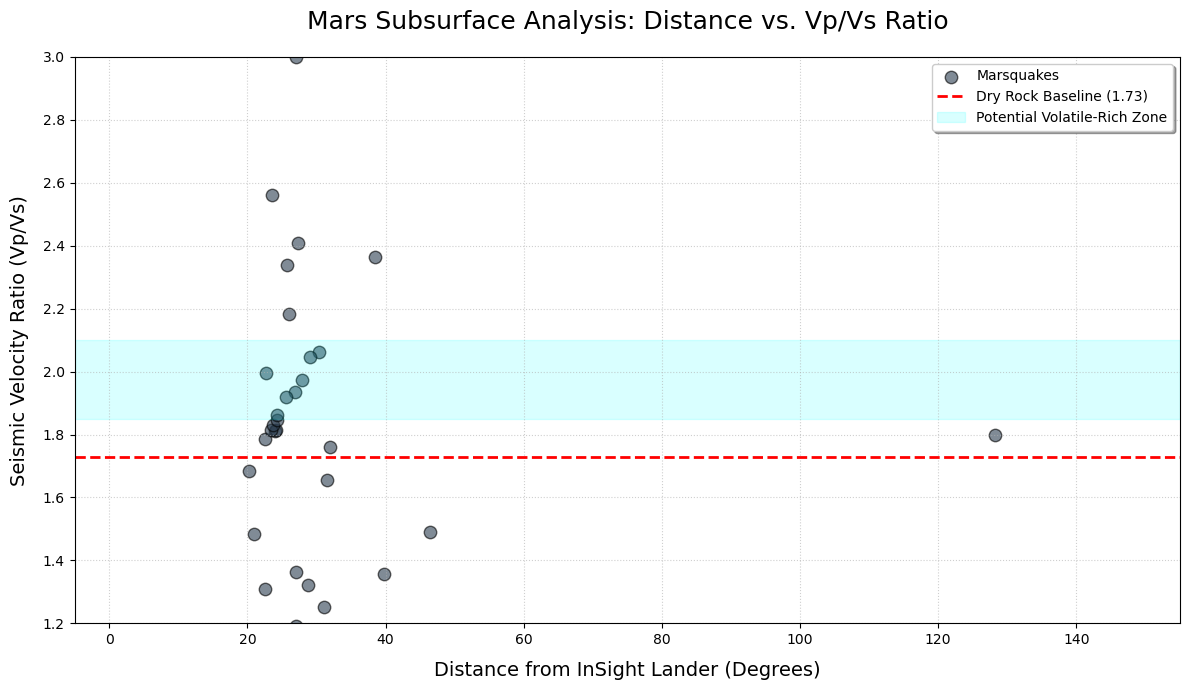

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load and clean the data
# Use the file you saved earlier
data = pd.read_csv('processed_marsquakes_vpvs.csv')
data['Vp_Vs_Ratio'] = pd.to_numeric(data['Vp_Vs_Ratio'], errors='coerce')

# Filter for "real-world" seismic ratios (usually between 1.4 and 3.0) 
# This removes the extreme outliers 
plot_data_clean = data[(data['Vp_Vs_Ratio'] > 1.0) & (data['Vp_Vs_Ratio'] < 5.0)].copy()

# 2. Create the plot
plt.figure(figsize=(12, 7))

# Plot all regular quakes
plt.scatter(plot_data_clean['Distance'], plot_data_clean['Vp_Vs_Ratio'], 
            alpha=0.6, c='#2c3e50', edgecolors='k', s=80, label='Marsquakes')

# 3. Highlight S1222a (The Monster Quake) in Red
if 'S1222a' in plot_data_clean['Event_ID'].values:
    monster = plot_data_clean[plot_data_clean['Event_ID'] == 'S1222a']
    mx, my = monster['Distance'].iloc[0], monster['Vp_Vs_Ratio'].iloc[0]
    
    plt.scatter(mx, my, color='red', edgecolors='black', s=200, label='S1222a (Monster Quake)', zorder=5)
    plt.annotate('Monster Quake (S1222a)', xy=(mx, my), xytext=(mx + 5, my + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, fontweight='bold')

# 4. Add the Dry Rock Baseline
plt.axhline(y=1.73, color='red', linestyle='--', linewidth=2, label='Dry Rock Baseline (1.73)')

# 5. Highlight the Volatile Zone (1.85 to 2.1)
plt.axhspan(1.85, 2.1, color='cyan', alpha=0.15, label='Potential Volatile-Rich Zone')

# 7. Final Formatting for Labels and Legend
plt.title('Mars Subsurface Analysis: Distance vs. Vp/Vs Ratio', fontsize=18, pad=20)
plt.xlabel('Distance from InSight Lander (Degrees)', fontsize=14, labelpad=10)
plt.ylabel('Seismic Velocity Ratio (Vp/Vs)', fontsize=14, labelpad=10)

plt.ylim(1.2, 3.0) 
plt.xlim(-5, 155)
plt.grid(True, linestyle=':', alpha=0.6)

# Place legend where it doesn't block the data
plt.legend(loc='upper right', frameon=True, fontsize=10, shadow=True)

# CRITICAL: This fixes the labels getting cut off
plt.tight_layout()

plt.show()

By applying a Vp Vs threshold of 1.85, we identified a population of seismic events that deviate from the dry-rock baseline of 1.73. This deviation is consistent with the presence of subsurface volatiles, specifically liquid brines, in the mid-to-lower Martian crust.